# Adapt Qutip example for BEC qubit

In [1]:
%pip freeze | grep qutip

qutip==5.1.1
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qp

## Run exmaple of stochastic master equation

[Example](https://qutip.readthedocs.io/en/qutip-5.0.x/guide/dynamics/dynamics-stochastic.html#example)
from documentation of [Stochastic Solver](https://qutip.readthedocs.io/en/qutip-5.0.x/guide/dynamics/dynamics-stochastic.html#stochastic-solver)

In [3]:
def stochastic_solution_example(dim=None, H=None):
    DIM = dim or 20  # Hilbert space dimension
    DELTA = 5 * 2 * np.pi  # cavity detuning
    KAPPA = 2  # cavity decay rate
    INTENSITY = 4  # intensity of initial state
    NUMBER_OF_TRAJECTORIES = 500

    # operators
    a = qp.destroy(DIM)
    x = a + a.dag()
    H = DELTA * a.dag() * a if H is None else H

    rho_0 = qp.coherent(DIM, np.sqrt(INTENSITY))
    times = np.arange(0, 1, 0.0025)

    solution = qp.smesolve(
        H,
        rho_0,
        times,
        c_ops=[],
        sc_ops=[np.sqrt(KAPPA) * a],
        e_ops=[x],
        ntraj=NUMBER_OF_TRAJECTORIES,
        options={
            "dt": 0.00125,
            "store_measurement": True,
        },
    )
    return solution

### Run default example

In [4]:
example_solution = stochastic_solution_example()

10.0%. Run time:   1.02s. Est. time left: 00:00:00:09
20.0%. Run time:   2.08s. Est. time left: 00:00:00:08
30.0%. Run time:   3.14s. Est. time left: 00:00:00:07
40.0%. Run time:   4.20s. Est. time left: 00:00:00:06
50.0%. Run time:   5.26s. Est. time left: 00:00:00:05
60.0%. Run time:   6.33s. Est. time left: 00:00:00:04
70.0%. Run time:   7.39s. Est. time left: 00:00:00:03
80.0%. Run time:   8.45s. Est. time left: 00:00:00:02
90.0%. Run time:   9.51s. Est. time left: 00:00:00:01
100.0%. Run time:  10.57s. Est. time left: 00:00:00:00
Total run time:  10.59s


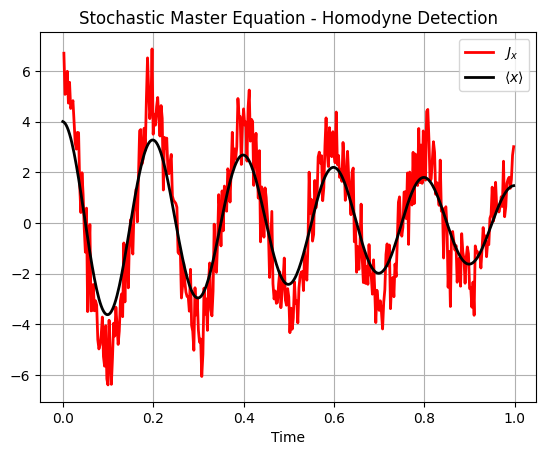

In [5]:
_, ax = plt.subplots()
ax.set_title("Stochastic Master Equation - Homodyne Detection")
ax.plot(
    example_solution.times[1:],
    np.array(example_solution.measurement).mean(axis=0)[0, :].real,
    "r",
    lw=2,
    label=r"$J_x$",
)
ax.plot(
    example_solution.times,
    example_solution.expect[0],
    "k",
    lw=2,
    label=r"$\langle x \rangle$",
)
ax.set_xlabel("Time")
ax.legend()
ax.grid()

### Run on low operator dimension

In [6]:
example_solution = stochastic_solution_example(dim=5)

10.0%. Run time:   0.56s. Est. time left: 00:00:00:05
20.0%. Run time:   1.12s. Est. time left: 00:00:00:04
30.0%. Run time:   1.69s. Est. time left: 00:00:00:03
40.0%. Run time:   2.26s. Est. time left: 00:00:00:03
50.0%. Run time:   2.83s. Est. time left: 00:00:00:02
60.0%. Run time:   3.39s. Est. time left: 00:00:00:02
70.0%. Run time:   3.96s. Est. time left: 00:00:00:01
80.0%. Run time:   4.53s. Est. time left: 00:00:00:01
90.0%. Run time:   5.10s. Est. time left: 00:00:00:00
100.0%. Run time:   5.67s. Est. time left: 00:00:00:00
Total run time:   5.68s


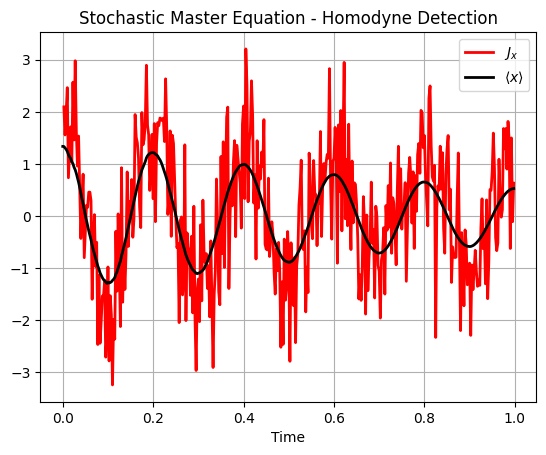

In [7]:
_, ax = plt.subplots()
ax.set_title("Stochastic Master Equation - Homodyne Detection")
ax.plot(
    example_solution.times[1:],
    np.array(example_solution.measurement).mean(axis=0)[0, :].real,
    "r",
    lw=2,
    label=r"$J_x$",
)
ax.plot(
    example_solution.times,
    example_solution.expect[0],
    "k",
    lw=2,
    label=r"$\langle x \rangle$",
)
ax.set_xlabel("Time")
ax.legend()
ax.grid()

### Run example without Hamiltonian

In [8]:
example_solution = stochastic_solution_example(20, qp.qeye(20))

10.0%. Run time:   1.04s. Est. time left: 00:00:00:09
20.0%. Run time:   2.09s. Est. time left: 00:00:00:08
30.0%. Run time:   3.15s. Est. time left: 00:00:00:07
40.0%. Run time:   4.21s. Est. time left: 00:00:00:06
50.0%. Run time:   5.27s. Est. time left: 00:00:00:05
60.0%. Run time:   6.33s. Est. time left: 00:00:00:04
70.0%. Run time:   7.38s. Est. time left: 00:00:00:03
80.0%. Run time:   8.44s. Est. time left: 00:00:00:02
90.0%. Run time:   9.49s. Est. time left: 00:00:00:01
100.0%. Run time:  10.57s. Est. time left: 00:00:00:00
Total run time:  10.60s


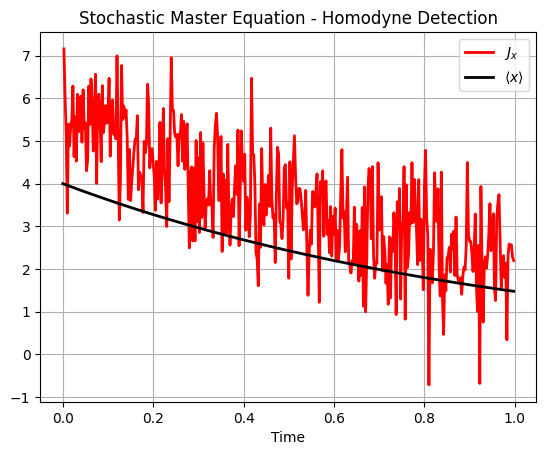

In [9]:
_, ax = plt.subplots()
ax.set_title("Stochastic Master Equation - Homodyne Detection")
ax.plot(
    example_solution.times[1:],
    np.array(example_solution.measurement).mean(axis=0)[0, :].real,
    "r",
    lw=2,
    label=r"$J_x$",
)
ax.plot(
    example_solution.times,
    example_solution.expect[0],
    "k",
    lw=2,
    label=r"$\langle x \rangle$",
)
ax.set_xlabel("Time")
ax.legend()
ax.grid()

## Migrate example to BEC qubit

In [10]:
import sys
from pathlib import Path

sys.path.extend([str(p) for p in (Path.cwd().parent / "dependencies").iterdir()])

In [11]:
%reload_ext autoreload
%autoreload 2

import bec

In [12]:
n_bosons = 5
model = bec.BEC_Qubits.init_default(n_bosons, 0)
model

BEC_Qubits(n_bosons=5, coupling_strength=1, transition_ampl=1, transition_freq=11, resonance_freq=1, phase=0, excitation_level=False, communication_line=False)

In [13]:
rho_0 = bec.coherent_state_constructor(model, n=1, k=0) * bec.vacuum_state(model, n=1)
rho_0.dag()

Quantum object: dims=[[1, 1], [6, 6]], shape=(1, 36), type='bra', dtype=Dense
Qobj data =
[[0.         0.         0.         0.         0.         0.1767767
  0.         0.         0.         0.         0.39528471 0.
  0.         0.         0.         0.55901699 0.         0.
  0.         0.         0.55901699 0.         0.         0.
  0.         0.39528471 0.         0.         0.         0.
  0.1767767  0.         0.         0.         0.         0.        ]]

### Measure $I_z$ without Hamiltonian

In [14]:
rho_0.dag() * bec.sz(model) * rho_0

(2.7755575615628914e-17+0j)

In [15]:
%%time

solution = qp.smesolve(
    qp.tensor(qp.qeye(n_bosons + 1), qp.qeye(n_bosons + 1)),  # identity
    rho_0,
    np.linspace(0, 1),
    c_ops=[],
    sc_ops=[np.sqrt(2) * bec.a(model)],
    e_ops=[bec.sz(model)],
    ntraj=500,
    options={
        "dt": 0.00125,
        "store_measurement": True,
    },
)

10.0%. Run time:   2.08s. Est. time left: 00:00:00:18
20.0%. Run time:   4.20s. Est. time left: 00:00:00:16
30.0%. Run time:   6.33s. Est. time left: 00:00:00:14
40.0%. Run time:   8.46s. Est. time left: 00:00:00:12
50.0%. Run time:  10.58s. Est. time left: 00:00:00:10
60.0%. Run time:  12.71s. Est. time left: 00:00:00:08
70.0%. Run time:  14.84s. Est. time left: 00:00:00:06
80.0%. Run time:  16.97s. Est. time left: 00:00:00:04
90.0%. Run time:  19.10s. Est. time left: 00:00:00:02
100.0%. Run time:  21.22s. Est. time left: 00:00:00:00
Total run time:  21.27s
CPU times: user 21.2 s, sys: 5.32 ms, total: 21.2 s
Wall time: 21.3 s


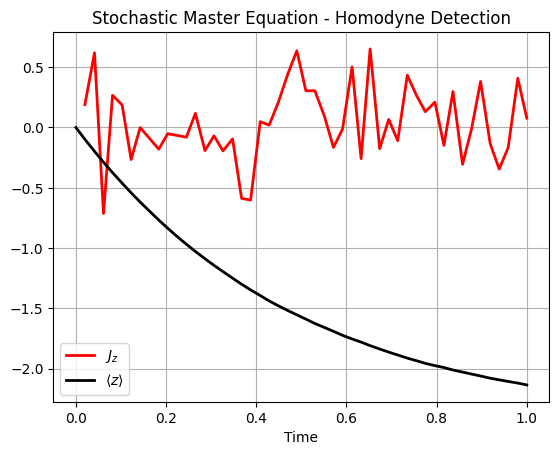

In [16]:
_, ax = plt.subplots()
ax.set_title("Stochastic Master Equation - Homodyne Detection")
ax.plot(
    solution.times[1:],
    np.array(solution.measurement).mean(axis=0)[0, :].real,
    "r",
    lw=2,
    label=r"$J_z$",
)
ax.plot(solution.times, solution.expect[0], "k", lw=2, label=r"$\langle z \rangle$")
ax.set_xlabel("Time")
ax.legend()
ax.grid()

### Measure $I_x$ without Hamiltonian

In [17]:
(rho_0.dag() * bec.sx(model) * rho_0)

(4.9999999999999964+0j)

In [18]:
solution = qp.smesolve(
    qp.tensor(qp.qeye(n_bosons + 1), qp.qeye(n_bosons + 1)),  # identity
    rho_0,
    np.linspace(0, 1),
    c_ops=[],
    sc_ops=[np.sqrt(2) * bec.a(model)],
    e_ops=[bec.sx(model)],
    ntraj=500,
    options={
        "dt": 0.00125,
        "store_measurement": True,
    },
)

10.0%. Run time:   2.08s. Est. time left: 00:00:00:18
20.0%. Run time:   4.22s. Est. time left: 00:00:00:16
30.0%. Run time:   6.35s. Est. time left: 00:00:00:14
40.0%. Run time:   8.49s. Est. time left: 00:00:00:12
50.0%. Run time:  10.62s. Est. time left: 00:00:00:10
60.0%. Run time:  12.75s. Est. time left: 00:00:00:08
70.0%. Run time:  14.88s. Est. time left: 00:00:00:06
80.0%. Run time:  17.01s. Est. time left: 00:00:00:04
90.0%. Run time:  19.14s. Est. time left: 00:00:00:02
100.0%. Run time:  21.27s. Est. time left: 00:00:00:00
Total run time:  21.31s


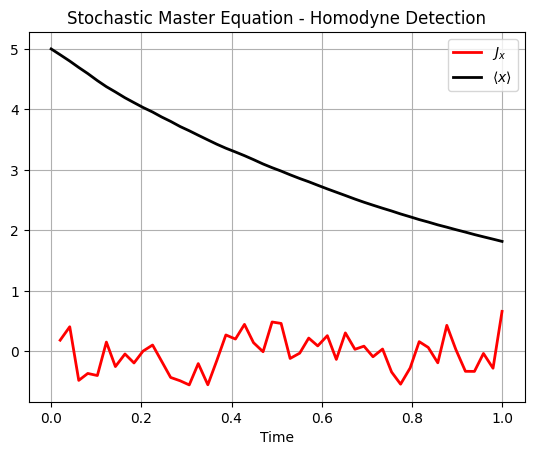

In [19]:
_, ax = plt.subplots()
ax.set_title("Stochastic Master Equation - Homodyne Detection")
ax.plot(
    solution.times[1:],
    np.array(solution.measurement).mean(axis=0)[0, :].real,
    "r",
    lw=2,
    label=r"$J_x$",
)
ax.plot(solution.times, solution.expect[0], "k", lw=2, label=r"$\langle x \rangle$")
ax.set_xlabel("Time")
ax.legend()
ax.grid()